In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [70]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "02_model_training"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Data Collection

In [3]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [4]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-09-29 23:15:00,65633.91,65639.54,65528.00,65549.92,104.95949
1,2024-09-29 23:30:00,65549.92,65615.53,65532.13,65615.52,126.79291
2,2024-09-29 23:45:00,65615.52,65731.55,65602.00,65602.01,108.84279
3,2024-09-30 00:00:00,65602.01,65618.80,65450.03,65500.01,219.13587
4,2024-09-30 00:15:00,65500.00,65524.00,65188.00,65239.88,363.48553


# Technical Indicators

### Momentum

In [5]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()


In [6]:
##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

In [7]:
## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

In [8]:
## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

In [9]:
## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

In [10]:
## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

In [11]:
## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

In [12]:
## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

In [13]:
## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [14]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

In [15]:
## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

In [16]:
##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

In [17]:
##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

In [18]:
##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

In [19]:
##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

In [20]:
##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

In [21]:
##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

In [22]:
## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [23]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

In [24]:
## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

In [25]:
## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

In [26]:
## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

In [27]:
## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [28]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

In [29]:
## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

In [30]:
## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

In [31]:
## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

In [32]:
## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

In [33]:
## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

In [34]:
## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

In [35]:
## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

In [36]:
## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

In [37]:
## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

In [38]:
## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

In [39]:
df.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-09-29 23:15:00,65633.91,65639.54,65528.00,65549.92,104.95949,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-09-29 23:30:00,65549.92,65615.53,65532.13,65615.52,126.79291,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-09-29 23:45:00,65615.52,65731.55,65602.00,65602.01,108.84279,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-09-30 00:00:00,65602.01,65618.80,65450.03,65500.01,219.13587,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-09-30 00:15:00,65500.00,65524.00,65188.00,65239.88,363.48553,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Constants

In [40]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Explore Data

### Correlation

In [41]:
# OCHLV with MOMENTUM
df[OCHLV + MOMENTUM].corr()

,open,close,high,low,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
open,1.000000,0.999884,0.999932,0.999923,-0.156613,0.019680,0.999751,0.016072,-0.002462,0.017296,0.006399,0.000122,0.007623,0.004988,0.008603,-0.012358,-0.001644,0.002440,0.013315
close,0.999884,1.000000,0.999937,0.999932,-0.156519,0.020082,0.999676,0.017052,0.000331,0.017445,0.006354,0.000121,0.007570,0.009258,0.013783,-0.005734,0.004425,0.004510,0.014345
high,0.999932,0.999937,1.000000,0.999871,-0.150451,0.019467,0.999716,0.016095,-0.001267,0.016938,0.009628,0.002588,0.010042,0.006836,0.010960,-0.008922,0.001082,0.003209,0.013492
low,0.999923,0.999932,0.999871,1.000000,-0.163228,0.020717,0.999671,0.017362,-0.000364,0.017998,0.002958,-0.002540,0.005063,0.008040,0.012098,-0.008681,0.001807,0.004017,0.014555
volume,-0.156613,-0.156519,-0.150451,-0.163228,1.000000,-0.009478,-0.155318,0.002071,-0.030406,0.011931,0.494042,0.413827,0.348704,-0.014782,-0.012557,-0.013642,-0.018935,-0.018763,0.000075
AO,0.019680,0.020082,0.019467,0.020717,-0.009478,1.000000,0.005982,0.963016,0.451514,0.878284,-0.053185,-0.002472,-0.061995,0.733072,0.746911,0.044425,0.426456,0.531789,0.869158
KAMA,0.999751,0.999676,0.999716,0.999671,-0.155318,0.005982,1.000000,0.002925,-0.016476,0.007808,0.008156,0.000814,0.009317,-0.009716,-0.005959,-0.020161,-0.014157,-0.012745,0.000783
PPO,0.016072,0.017052,0.016095,0.017362,0.002071,0.963016,0.002925,1.000000,0.338630,0.953658,-0.042965,0.004784,-0.054013,0.700566,0.752355,0.013035,0.399357,0.483117,0.885107
PPO_HIST,-0.002462,0.000331,-0.001267,-0.000364,-0.030406,0.451514,-0.016476,0.338630,1.000000,0.039821,-0.056304,-0.044089,-0.041527,0.826541,0.562421,0.588637,0.638089,0.685970,0.309444
PPO_SIGNAL,0.017296,0.017445,0.016938,0.017998,0.011931,0.878284,0.007808,0.953658,0.039821,1.000000,-0.027612,0.019180,-0.044079,0.479784,0.619055,-0.174181,0.220188,0.293802,0.841003


In [42]:
# OCHLV with VOLUME
df[OCHLV + VOLUME].corr()

,open,close,high,low,volume,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
open,1.000000,0.999884,0.999932,0.999923,-0.156613,0.626738,0.030674,-0.005242,0.011752,0.008704,0.005438,0.748160,0.384431,0.740602,0.999721
close,0.999884,1.000000,0.999937,0.999932,-0.156519,0.626652,0.033223,0.004249,0.014027,0.013196,0.007550,0.748180,0.384442,0.740651,0.999640
high,0.999932,0.999937,1.000000,0.999871,-0.150451,0.628046,0.031516,0.000529,0.012700,0.010994,0.006389,0.747258,0.386063,0.741769,0.999680
low,0.999923,0.999932,0.999871,1.000000,-0.163228,0.625410,0.031776,0.001256,0.014147,0.011853,0.007361,0.749278,0.382612,0.739307,0.999648
volume,-0.156613,-0.156519,-0.150451,-0.163228,1.000000,-0.035848,0.025996,-0.030534,-0.055822,0.060799,-0.016547,-0.245341,0.105738,0.018106,-0.155924
ADI,0.626738,0.626652,0.628046,0.625410,-0.035848,1.000000,-0.045115,0.000138,0.000221,-0.027917,-0.020576,0.335978,0.657744,0.719287,0.626162
CMF,0.030674,0.033223,0.031516,0.031776,0.025996,-0.045115,1.000000,0.135210,0.421526,0.265366,0.554657,-0.033043,0.032942,0.042536,0.021450
EoM,-0.005242,0.004249,0.000529,0.001256,-0.030534,0.000138,0.135210,1.000000,0.242626,0.205668,0.133563,0.002866,-0.001935,-0.001063,-0.007860
EMV,0.011752,0.014027,0.012700,0.014147,-0.055822,0.000221,0.421526,0.242626,1.000000,0.403704,0.685532,0.006548,-0.004305,0.001151,-0.005348
FI,0.008704,0.013196,0.010994,0.011853,0.060799,-0.027917,0.265366,0.205668,0.403704,1.000000,0.316658,-0.011396,0.007296,0.030182,-0.001370


In [43]:
# OCHLV with VOLATILITY
df[OCHLV + VOLATILITY].corr()

,open,close,high,low,volume,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
open,1.000000,0.999884,0.999932,0.999923,-0.156613,-0.014211,0.998872,-0.000335,0.998795,-0.006597,...,-0.001114,-0.203066,0.999319,0.008708,0.999346,0.007624,0.999392,0.007772,-0.253734,-0.155878
close,0.999884,1.000000,0.999937,0.999932,-0.156519,-0.014132,0.998778,0.004184,0.998693,-0.011281,...,0.004279,-0.202880,0.999218,0.012200,0.999244,0.003898,0.999290,0.013218,-0.253636,-0.156287
high,0.999932,0.999937,1.000000,0.999871,-0.150451,-0.008898,0.998972,0.003520,0.998610,-0.007562,...,0.001233,-0.198299,0.999329,0.010971,0.999248,0.006723,0.999348,0.010377,-0.248992,-0.152949
low,0.999923,0.999932,0.999871,1.000000,-0.163228,-0.019690,0.998631,0.000741,0.998839,-0.010782,...,0.002118,-0.207825,0.999164,0.010332,0.999302,0.004348,0.999292,0.011239,-0.258538,-0.159445
volume,-0.156613,-0.156519,-0.150451,-0.163228,1.000000,0.538088,-0.138763,0.209047,-0.172180,0.203271,...,-0.022178,0.582177,-0.150305,0.094952,-0.161068,0.144429,-0.155614,-0.005132,0.518447,0.331243
ATR,-0.014211,-0.014132,-0.008898,-0.019690,0.538088,1.000000,0.012170,0.005155,-0.041136,0.014885,...,0.000007,0.855066,-0.002050,0.000976,-0.023636,0.047111,-0.014523,-0.021349,0.942710,0.657441
BBANDS_HIGH,0.998872,0.998778,0.998972,0.998631,-0.138763,0.012170,1.000000,-0.008794,0.997660,0.001739,...,-0.023019,-0.172032,0.999650,-0.006309,0.999050,0.032501,0.999411,-0.019131,-0.226688,-0.117296
BBANDS_HIGH_INDI,-0.000335,0.004184,0.003520,0.000741,0.209047,0.005155,-0.008794,1.000000,-0.009112,-0.062508,...,0.342452,0.027468,-0.009095,0.409041,-0.008689,-0.141142,-0.009191,0.427617,-0.013852,-0.119073
BBANDS_LOWER,0.998795,0.998693,0.998610,0.998839,-0.172180,-0.041136,0.997660,-0.009112,1.000000,0.001617,...,-0.023998,-0.234474,0.999057,-0.016022,0.999656,0.022958,0.999417,-0.020857,-0.278675,-0.159271
BBANDS_LOWER_INDI,-0.006597,-0.011281,-0.007562,-0.010782,0.203271,0.014885,0.001739,-0.062508,0.001617,1.000000,...,-0.379175,0.020554,0.002107,-0.152204,0.002292,0.442031,0.001913,-0.430309,-0.009196,0.059032


In [44]:
# OCHLV with TREND
df[OCHLV + TREND].corr()

,open,close,high,low,volume,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
open,1.000000,0.999884,0.999932,0.999923,-0.156613,-0.028720,0.043788,0.036559,0.006027,0.004536,...,-0.024742,0.023850,0.025617,-0.002076,-0.004467,0.999631,0.007561,-0.006901,0.007345,0.999811
close,0.999884,1.000000,0.999937,0.999932,-0.156519,-0.028738,0.046781,0.033480,0.006828,0.003737,...,-0.023885,0.024835,0.025761,0.000742,-0.004499,0.999536,0.009477,-0.008853,0.009308,0.999730
high,0.999932,0.999937,1.000000,0.999871,-0.150451,-0.026881,0.045810,0.035521,0.007271,0.005037,...,-0.024592,0.023865,0.025250,-0.000883,-0.001941,0.999585,0.007862,-0.008544,0.008325,0.999768
low,0.999923,0.999932,0.999871,1.000000,-0.163228,-0.030599,0.046016,0.033098,0.005995,0.002705,...,-0.023848,0.025161,0.026334,0.000040,-0.007130,0.999541,0.010158,-0.008092,0.009275,0.999736
volume,-0.156613,-0.156519,-0.150451,-0.163228,1.000000,0.246346,0.052412,0.100554,0.112863,0.111262,...,-0.015350,-0.004991,0.004972,-0.032039,0.285066,-0.155744,-0.078682,-0.053892,-0.013268,-0.155990
ADX,-0.028720,-0.028738,-0.026881,-0.030599,0.246346,1.000000,0.020471,0.035386,-0.005758,0.026350,...,-0.005179,-0.032531,-0.031557,-0.008878,0.373083,-0.030153,-0.006463,-0.010493,0.001958,-0.030358
ADX_POS,0.043788,0.046781,0.045810,0.046016,0.052412,0.020471,1.000000,-0.728328,0.582783,-0.522053,...,0.356323,0.716671,0.611203,0.468223,-0.009206,0.024276,0.734104,-0.775370,0.766052,0.030404
ADX_NEG,0.036559,0.033480,0.035521,0.033098,0.100554,0.035386,-0.728328,1.000000,-0.513257,0.580163,...,-0.363220,-0.693774,-0.579849,-0.490090,0.114653,0.051862,-0.761249,0.735318,-0.759847,0.045725
AROON_UP,0.006027,0.006828,0.007271,0.005995,0.112863,-0.005758,0.582783,-0.513257,1.000000,-0.458299,...,0.267195,0.555513,0.518085,0.224446,0.042656,-0.003167,0.495320,-0.555147,0.532953,0.000603
AROON_DOWN,0.004536,0.003737,0.005037,0.002705,0.111262,0.026350,-0.522053,0.580163,-0.458299,1.000000,...,-0.284994,-0.570259,-0.528525,-0.241118,0.221576,0.014223,-0.556412,0.512225,-0.542715,0.010257


In [45]:
dataset = df.copy()

# Data Cleaning

In [46]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35040 non-null  datetime64[ns]
 1   open                 35040 non-null  float64       
 2   high                 35040 non-null  float64       
 3   low                  35040 non-null  float64       
 4   close                35040 non-null  float64       
 5   volume               35040 non-null  float64       
 6   AO                   35007 non-null  float64       
 7   KAMA                 35031 non-null  float64       
 8   PPO                  35015 non-null  float64       
 9   PPO_HIST             35007 non-null  float64       
 10  PPO_SIGNAL           35007 non-null  float64       
 11  PVO                  35015 non-null  float64       
 12  PVO_HIST             35007 non-null  float64       
 13  PVO_SIGNAL           35007 non-

In [47]:
dataset = DataCleaning(dataset).clean_data()

In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 40 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35000 non-null  datetime64[ns]
 1   open                 35000 non-null  float64       
 2   high                 35000 non-null  float64       
 3   low                  35000 non-null  float64       
 4   close                35000 non-null  float64       
 5   volume               35000 non-null  float64       
 6   AO                   35000 non-null  float64       
 7   KAMA                 35000 non-null  float64       
 8   PPO                  35000 non-null  float64       
 9   PPO_HIST             35000 non-null  float64       
 10  PPO_SIGNAL           35000 non-null  float64       
 11  PVO                  35000 non-null  float64       
 12  PVO_HIST             35000 non-null  float64       
 13  PVO_SIGNAL           35000 non-null

# Feature Engineering

### Timestamp Features

In [49]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [50]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df


In [51]:
targets = create_targets(dataset, target_column='close', n_steps=16)

In [52]:
targets.tail(20)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35020,2025-09-29 18:15:00,114031.25,114057.00,113867.02,113963.41,152.07052,830.980000,113748.426257,0.321290,-0.037478,...,114369.00,114290.07,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50
35021,2025-09-29 18:30:00,113963.40,114017.20,113892.49,113984.46,62.55268,822.057941,113749.546007,0.307420,-0.041078,...,114290.07,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44
35022,2025-09-29 18:45:00,113984.46,114059.86,113984.45,114008.79,70.04058,797.327559,113757.805952,0.294748,-0.043000,...,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81
35023,2025-09-29 19:00:00,114008.78,114079.99,113940.05,114009.66,124.16508,736.686353,113778.214255,0.281516,-0.044986,...,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81
35024,2025-09-29 19:15:00,114009.66,114028.97,113848.63,114004.55,87.22981,664.551882,113830.162764,0.267577,-0.047140,...,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81,NaN
35025,2025-09-29 19:30:00,114004.54,114151.24,113884.08,114151.23,117.71063,616.728353,113902.660662,0.263874,-0.040674,...,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81,NaN,NaN
35026,2025-09-29 19:45:00,114151.23,114390.93,114151.23,114265.55,418.82886,613.096971,113985.581349,0.265957,-0.030873,...,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81,NaN,NaN,NaN
35027,2025-09-29 20:00:00,114265.56,114400.00,114122.12,114369.00,124.45322,595.200471,114081.681980,0.271780,-0.020040,...,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81,NaN,NaN,NaN,NaN
35028,2025-09-29 20:15:00,114369.00,114369.01,114220.79,114290.07,83.31177,587.088971,114103.314237,0.267706,-0.019291,...,114130.60,114090.50,114050.44,114189.81,114189.81,NaN,NaN,NaN,NaN,NaN
35029,2025-09-29 20:30:00,114290.08,114400.00,114260.00,114393.51,178.59370,599.530882,114147.915161,0.268685,-0.014650,...,114090.50,114050.44,114189.81,114189.81,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
dataset = DataCleaning(targets).clean_data()

In [54]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35019,2025-09-29 18:00:00,114043.92,114137.73,113921.55,114031.25,112.22773,826.402618,113743.313715,0.336193,-0.031944,...,114265.55,114369.00,114290.07,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60
35020,2025-09-29 18:15:00,114031.25,114057.00,113867.02,113963.41,152.07052,830.980000,113748.426257,0.321290,-0.037478,...,114369.00,114290.07,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50
35021,2025-09-29 18:30:00,113963.40,114017.20,113892.49,113984.46,62.55268,822.057941,113749.546007,0.307420,-0.041078,...,114290.07,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44
35022,2025-09-29 18:45:00,113984.46,114059.86,113984.45,114008.79,70.04058,797.327559,113757.805952,0.294748,-0.043000,...,114393.51,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81
35023,2025-09-29 19:00:00,114008.78,114079.99,113940.05,114009.66,124.16508,736.686353,113778.214255,0.281516,-0.044986,...,114258.29,114186.57,114153.98,114181.42,114176.73,114130.60,114090.50,114050.44,114189.81,114189.81


# Feature Selection

In [55]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

### Splitting X, y

In [56]:
dataset = dataset.sort_values('timestamp')

In [57]:
DROP_COLUMNS = ['timestamp', 'close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']

In [58]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [ ]:
xgb_close = XGBRegressor(eval_metric="rmse", early_stopping_rounds=100)

In [60]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [61]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum

##### Training to predict close_step_1

In [62]:
X, y = X_y_split(dataset, target='close_step_1', drop_columns=DROP_COLUMNS)

In [ ]:
fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_close, tscv)

##### Error metrics by fold (100 folds)

In [64]:
valid_mask = ~np.isnan(oof_pred)
rmse_cv = root_mean_squared_error(y[valid_mask], oof_pred[valid_mask])
mae_cv  = mean_absolute_error(y[valid_mask], oof_pred[valid_mask])

In [65]:
metrics_df = pd.DataFrame(fold_metrics)

In [66]:
metrics_df.head()

,fold,rmse,mae
0,1,424.588451,334.512108
1,2,290.730773,182.621923
2,3,925.463371,566.677919
3,4,1602.982040,1450.284757
4,5,212.016136,158.275499


##### Feature importance average

In [67]:
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)

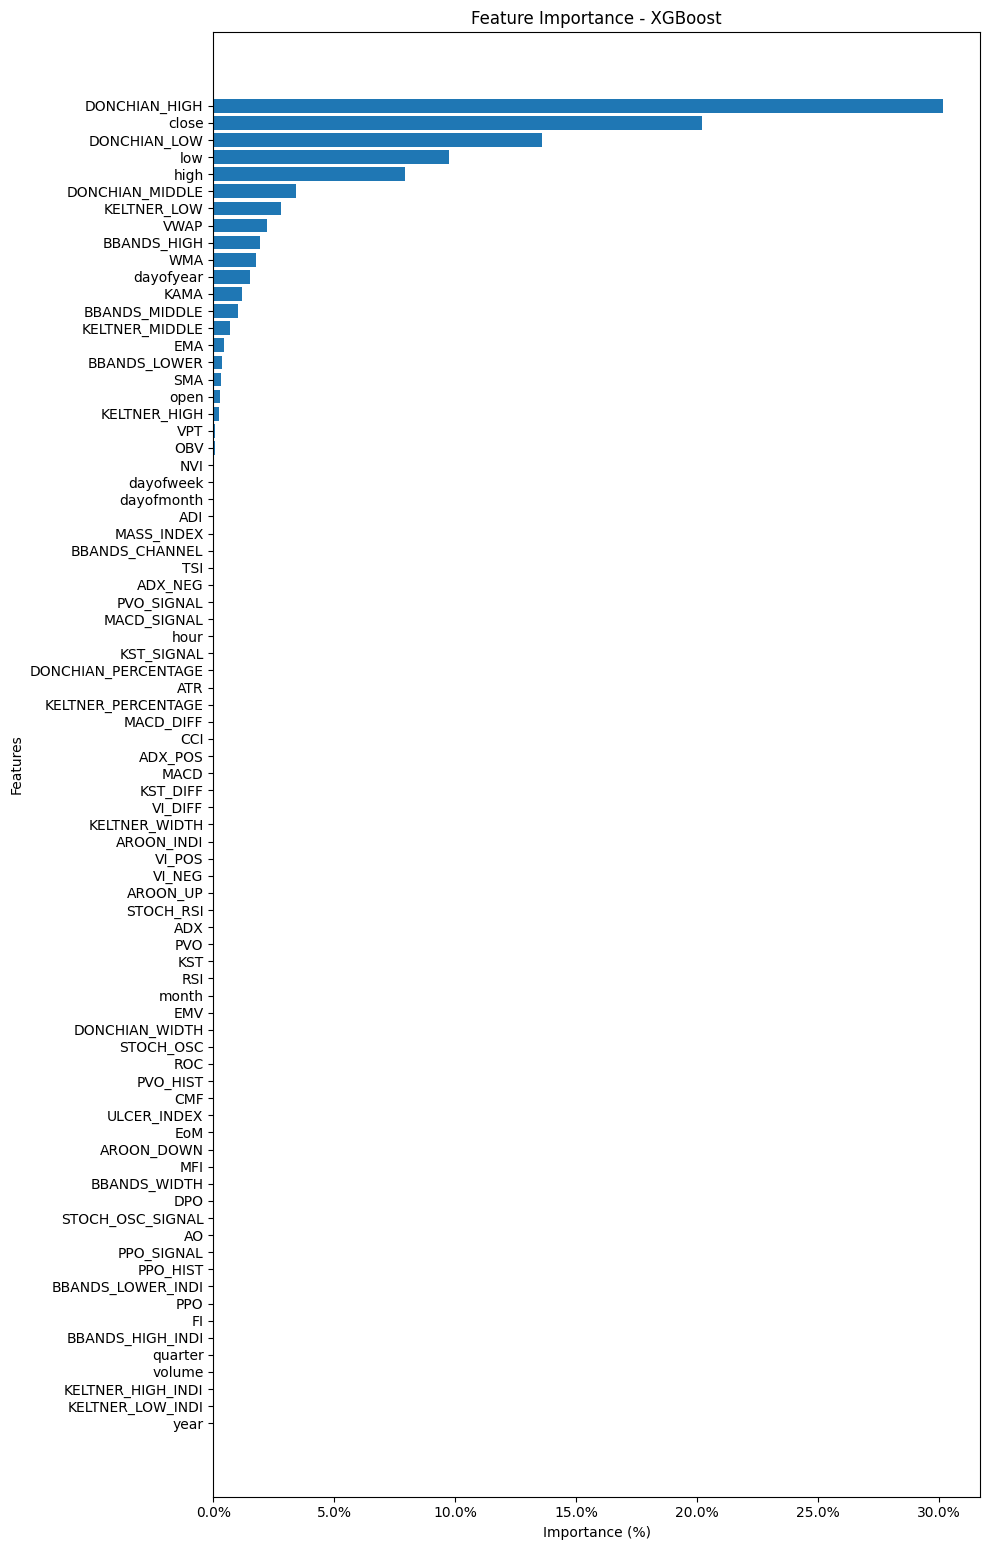

In [72]:
import matplotlib.ticker as ticker

importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100

plt.figure(figsize=(10, 0.2 * len(importance_df)))

plt.barh(importance_df["feature"], importance_df["gain_pct"])
plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

# Show x-axis as percentage with 1 decimal
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()


In [73]:
importance_df.head(20)

,feature,avg_gain,gain_pct
0,DONCHIAN_HIGH,2.115515e+10,30.175870
1,close,1.414998e+10,20.183639
2,DONCHIAN_LOW,9.532903e+09,13.597806
3,low,6.841273e+09,9.758444
4,high,5.564343e+09,7.937021
5,DONCHIAN_MIDDLE,2.382174e+09,3.397951
6,KELTNER_LOW,1.971612e+09,2.812322
7,VWAP,1.569749e+09,2.239103
8,BBANDS_HIGH,1.343285e+09,1.916072
9,WMA,1.226241e+09,1.749120


In [74]:
selected_features = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()
selected_features

['DONCHIAN_HIGH',
 'close',
 'DONCHIAN_LOW',
 'low',
 'high',
 'DONCHIAN_MIDDLE',
 'KELTNER_LOW',
 'VWAP',
 'BBANDS_HIGH',
 'WMA',
 'dayofyear',
 'KAMA',
 'BBANDS_MIDDLE',
 'KELTNER_MIDDLE']

### Hyperparameter tuning

In [75]:
cutoff_date = dataset['timestamp'].quantile(0.8)
close_train = dataset[dataset['timestamp'] < cutoff_date]
close_test = dataset[dataset['timestamp'] >= cutoff_date]

In [78]:
X_close_train = close_train[selected_features]
y_close_train = close_train['close_step_1']
X_close_test = close_test[selected_features]
y_close_test = close_test['close_step_1']

In [79]:
params = {
    "n_estimators": [200, 500, 800, 1000, 2000, 5000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10, 15],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.5, 1, 1.5, 2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 5, 10],
    "reg_alpha": [0, 0.5, 1, 5]
}

In [80]:
tscv_hyperparameter_tuning = TimeSeriesSplit(n_splits=100)

In [84]:
xgb_hyperparameter_tuning = XGBRegressor(objective='reg:squarederror')

In [86]:
hyperparameter_tuning_close_step_1 = RandomizedSearchCV(xgb_hyperparameter_tuning, param_distributions=params, n_iter=10, scoring='neg_root_mean_squared_error', cv=tscv_hyperparameter_tuning, verbose=3)

In [87]:
hyperparameter_tuning_close_step_1.fit(X_close_train, y_close_train)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits
[CV 1/100] END colsample_bytree=0.6, gamma=2, learning_rate=0.1, max_depth=5, min_child_weight=10, n_estimators=800, reg_alpha=1, reg_lambda=1, subsample=0.6;, score=-327.753 total time=   0.2s
[CV 2/100] END colsample_bytree=0.6, gamma=2, learning_rate=0.1, max_depth=5, min_child_weight=10, n_estimators=800, reg_alpha=1, reg_lambda=1, subsample=0.6;, score=-301.382 total time=   0.2s
[CV 3/100] END colsample_bytree=0.6, gamma=2, learning_rate=0.1, max_depth=5, min_child_weight=10, n_estimators=800, reg_alpha=1, reg_lambda=1, subsample=0.6;, score=-253.716 total time=   0.3s
[CV 4/100] END colsample_bytree=0.6, gamma=2, learning_rate=0.1, max_depth=5, min_child_weight=10, n_estimators=800, reg_alpha=1, reg_lambda=1, subsample=0.6;, score=-802.938 total time=   0.2s
[CV 5/100] END colsample_bytree=0.6, gamma=2, learning_rate=0.1, max_depth=5, min_child_weight=10, n_estimators=800, reg_alpha=1, reg_lambda=1, subsample=0.6;,

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=100, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, ga...
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.5, 1, 1.5, 2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 10, 15],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [200, 500, 800, 1000,
                                                         2000, 5000],
                                        'reg_alpha': [0, 0.5, 1, 5],
                                        'reg_lambda': [0, 1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_root_mean_squared_error', verbose=3)

In [88]:
print('\n Best hyperparameters:')
print(hyperparameter_tuning_close_step_1.best_params_)
results = pd.DataFrame(hyperparameter_tuning_close_step_1.cv_results_)
results


 Best hyperparameters:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_reg_lambda,param_reg_alpha,param_n_estimators,param_min_child_weight,param_max_depth,...,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score,mean_test_score,std_test_score,rank_test_score
0,0.579526,0.163391,0.002719,0.002960,0.6,1,1,800,10,5,...,-149.895404,-191.045492,-124.524048,-232.468150,-5574.173877,-1935.733813,-647.641235,-585.997600,956.389072,2
1,1.016502,0.294028,0.003643,0.003193,0.6,0,1,1000,10,7,...,-161.624296,-198.628914,-135.077154,-315.715657,-5590.459084,-1941.952198,-687.663749,-609.173696,959.948964,6
2,2.593495,0.925605,0.004568,0.003608,0.6,1,0,5000,10,3,...,-160.572485,-184.351017,-129.046685,-219.700731,-5510.979714,-1958.438265,-637.409799,-602.307075,955.617220,3
3,10.475698,3.251420,0.021072,0.006563,1.0,10,1,5000,10,15,...,-221.994395,-214.490819,-169.215512,-294.112516,-5721.986238,-1923.292686,-736.524179,-638.863155,968.017538,8
4,0.355847,0.091436,0.003194,0.004054,1.0,1,1,500,10,5,...,-141.674329,-166.482507,-120.982391,-199.916072,-5556.541568,-1934.861331,-623.517709,-567.429749,957.164939,1
5,0.470554,0.175843,0.002567,0.002577,0.8,1,0,200,3,10,...,-2142.966055,-2271.938846,-2214.892063,-2340.524588,-8110.999355,-5047.548287,-3616.274027,-1923.868243,1442.364210,9
6,1.359418,0.408965,0.003789,0.003429,0.6,10,5,500,5,10,...,-164.511769,-229.815379,-128.295062,-300.116077,-5636.535644,-1928.162544,-598.527295,-608.466204,971.465648,5
7,1.998508,0.532977,0.005204,0.003420,1.0,10,1,5000,3,3,...,-160.387225,-170.646446,-127.151096,-219.427004,-5550.051824,-1954.143535,-614.928026,-603.735089,964.978728,4
8,0.143341,0.044059,0.002658,0.001788,0.6,0,0,200,1,3,...,-2297.373645,-2675.197468,-2396.332391,-2883.105997,-9811.959590,-6948.401438,-4865.686661,-2112.591231,1721.340862,10
9,3.154765,1.783401,0.005865,0.003432,1.0,1,0,800,5,15,...,-222.827388,-212.339088,-169.642426,-249.505024,-5615.727378,-1929.710554,-629.973779,-609.372388,964.657810,7


### Model Creation

In [90]:
best_params = hyperparameter_tuning_close_step_1.best_params_

In [91]:
xgb_open_close_step_1 = XGBRegressor(objective='reg:squarederror', **best_params)

In [92]:
xgb_open_close_step_1.fit(X_close_train, y_close_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [93]:
y_pred = xgb_open_close_step_1.predict(X_close_test)

### Validating the model

In [96]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [103]:
mse = mean_squared_error(y_close_test, y_pred)
rmse = root_mean_squared_error(y_close_test, y_pred)
mae = mean_absolute_error(y_close_test, y_pred)
r2 = r2_score(y_close_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Squared Error (MSE): 364150.49
Root Mean Squared Error (RMSE): 603.45
Mean Absolute Error (MAE): 424.33
R-squared (R2 Score): 0.97


### Comparing results

In [106]:
dataset_compare = close_test.copy()

In [107]:
dataset_compare["close_step_1_pred"] = y_pred

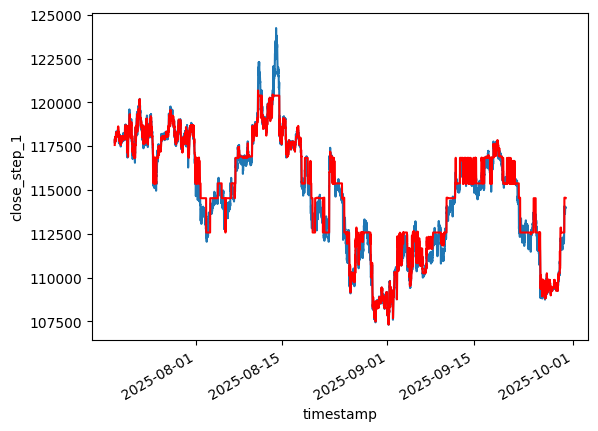

In [112]:
sns.lineplot(x="timestamp", y="close_step_1", data=dataset_compare)
sns.lineplot(x="timestamp", y="close_step_1_pred", data=dataset_compare, color="red")
plt.gcf().autofmt_xdate()
plt.show()

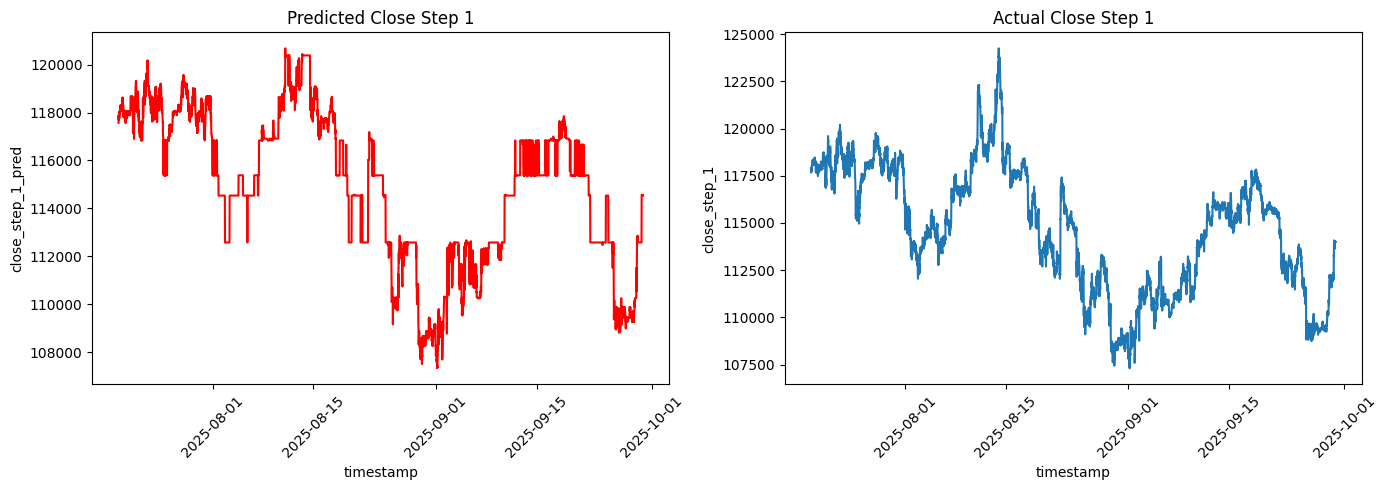

In [111]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# First plot (predicted)
sns.lineplot(x="timestamp", y="close_step_1_pred", 
             data=dataset_compare, color="red", ax=axes[0])
axes[0].set_title("Predicted Close Step 1")
axes[0].tick_params(axis='x', rotation=45)

# Second plot (actual)
sns.lineplot(x="timestamp", y="close_step_1", 
             data=dataset_compare, ax=axes[1])
axes[1].set_title("Actual Close Step 1")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()